<a href="https://colab.research.google.com/github/Manish-248/Deep-Learning-with-TensorFlow-End-to-End-MNIST-Classification-Pipeline/blob/main/Deep_Learning_with_TensorFlow_End_to_End_MNIST_Classification_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.20.0

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)

After preprocessing: (60000, 784)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9023 - loss: 0.3254 - val_accuracy: 0.9596 - val_loss: 0.1312
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9551 - loss: 0.1537 - val_accuracy: 0.9663 - val_loss: 0.1047
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9627 - loss: 0.1220 - val_accuracy: 0.9722 - val_loss: 0.0939
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9692 - loss: 0.1010 - val_accuracy: 0.9755 - val_loss: 0.0893
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9731 - loss: 0.0895 - val_accuracy: 0.9745 - val_loss: 0.0901
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9760 - loss: 0.0769 - val_accuracy: 0.9737 - val_loss: 0.0909
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9776 - loss: 0.0713 - val_accuracy: 0.9778 - val_loss: 0.0841
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9784 - loss: 0

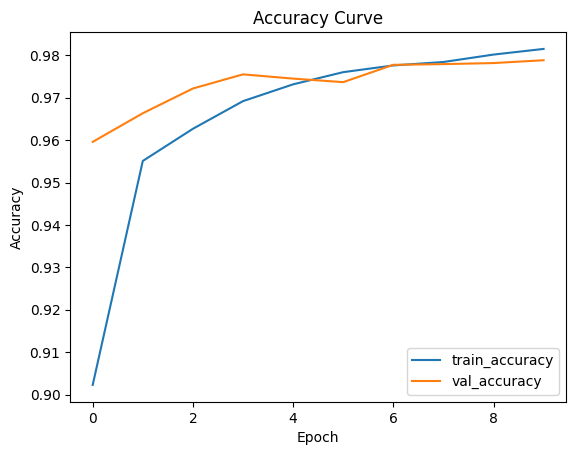

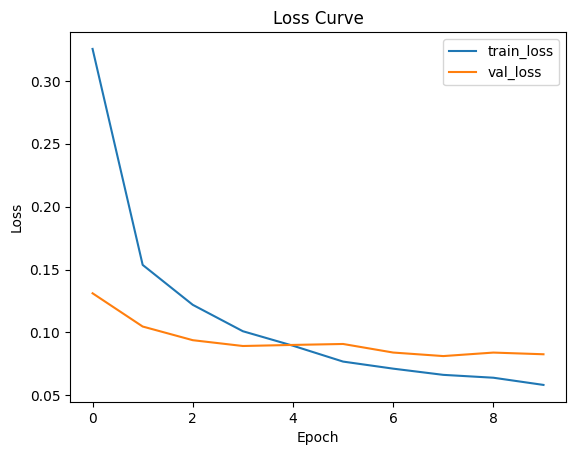


Model saved successfully!
Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

Predictions for first 5 samples:
[7 2 1 0 4]
Actual labels:
[7 2 1 0 4]

TensorFlow Deep Learning Pipeline Completed 🚀


In [2]:
"""
================================================================================
NOTEBOOK 3: Deep Learning with TensorFlow
Author: Manish Chandra

Description:
This notebook demonstrates an end-to-end deep learning pipeline using TensorFlow:
- Data Loading (MNIST dataset)
- Data Preprocessing
- Neural Network Design
- Training & Validation
- Performance Evaluation
- Visualization
- Model Saving & Loading

================================================================================
"""

# ==============================================================================
# 📌 1. IMPORT LIBRARIES
# ==============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# ==============================================================================
# 📌 2. LOAD DATASET (MNIST)
# ==============================================================================

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("\nTraining data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

# ==============================================================================
# 📌 3. DATA PREPROCESSING
# ==============================================================================

# Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images (28x28 → 784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

print("\nAfter preprocessing:", X_train.shape)

# ==============================================================================
# 📌 4. MODEL ARCHITECTURE
# ==============================================================================

model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.summary()

# ==============================================================================
# 📌 5. COMPILE MODEL
# ==============================================================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================================================================
# 📌 6. TRAIN MODEL
# ==============================================================================

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# ==============================================================================
# 📌 7. EVALUATION
# ==============================================================================

test_loss, test_acc = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", test_acc)

# ==============================================================================
# 📌 8. VISUALIZATION
# ==============================================================================

# Accuracy plot
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ==============================================================================
# 📌 9. MODEL SAVING
# ==============================================================================

model.save("mnist_model.h5")
print("\nModel saved successfully!")

# ==============================================================================
# 📌 10. MODEL LOADING
# ==============================================================================

loaded_model = keras.models.load_model("mnist_model.h5")
print("Model loaded successfully!")

# ==============================================================================
# 📌 11. PREDICTION DEMO
# ==============================================================================

predictions = loaded_model.predict(X_test[:5])

print("\nPredictions for first 5 samples:")
print(np.argmax(predictions, axis=1))
print("Actual labels:")
print(y_test[:5])

# ==============================================================================
# ✅ END
# ==============================================================================

print("\nTensorFlow Deep Learning Pipeline Completed 🚀")